# 🌍 Ülke Verisiyle Denetimsiz Öğrenme — PCA & K-Means / Unsupervised Learning on Country Data — PCA & K-Means

**🇹🇷 Türkçe:**
Bu practice notebook'u, 167 ülkeye ait sosyoekonomik göstergeleri (çocuk ölüm oranı, ihracat, sağlık harcaması, ithalat, gelir, enflasyon, yaşam beklentisi, doğurganlık, GSYİH) kullanarak "hangi ülkelerin mali yardıma daha çok ihtiyacı var?" sorusuna denetimsiz bir yaklaşımla cevap arıyor. Akış: özellikleri ölçekle → **PCA** ile boyut indirge → **K-Means** ile kümele → sonuçları hem sayısal hem de interaktif bir dünya haritasıyla yorumla.

**🇬🇧 English:**
This practice notebook uses socioeconomic indicators for 167 countries (child mortality, exports, health spending, imports, income, inflation, life expectancy, fertility, GDP per capita) to explore "which countries need financial aid most?" with an unsupervised approach. Flow: scale the features → reduce dimensionality with **PCA** → cluster with **K-Means** → interpret the results both numerically and with an interactive world map.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme (`pandas`, `numpy`) ve görselleştirme (`matplotlib`, `seaborn`) için gerekli kütüphaneler yükleniyor.

**🇬🇧 English:**
Loading the libraries needed for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
`29-country_data.csv` okunuyor — 167 ülke ve 9 sayısal sosyoekonomik gösterge artı `country` adı kolonu.

**🇬🇧 English:**
`29-country_data.csv` is loaded — 167 countries with 9 numeric socioeconomic indicators plus a `country` name column.

In [2]:
df = pd.read_csv("../../../Data/29-country_data.csv")

## 🔍 2. İlk Bakış / First Look

**🇹🇷 Türkçe:**
`head()`, `info()` ve `describe()` ile veri setinin yapısı kontrol ediliyor: 167 satır, eksik değer yok, kolonlar farklı ölçeklerde (`income` binlerce, `total_fer` tek haneli) — bu, ileride ölçekleme adımının neden gerekli olduğunu gösteriyor.

**🇬🇧 English:**
`head()`, `info()`, and `describe()` check the dataset's structure: 167 rows, no missing values, columns on very different scales (`income` in the thousands, `total_fer` a single digit) — a preview of why the scaling step later matters.

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## 🏷️ 3. Ülke Adını Bir Kenara Ayırma / Setting the Country Name Aside

**🇹🇷 Türkçe:**
`country` metin kolonu, PCA/K-Means gibi sayısal yöntemlerde kullanılamayacağı için `country_column` değişkeninde saklanıp DataFrame'den çıkarılıyor. Böylece geriye sadece sayısal göstergeler kalıyor; ülke isimleri sonuçları yorumlarken (ve haritada) geri eklenecek.

**🇬🇧 English:**
The `country` text column can't be used by numeric methods like PCA/K-Means, so it's saved into `country_column` and dropped from the DataFrame. That leaves only numeric indicators; the country names will be re-attached later when interpreting the results (and on the map).

In [6]:
country_column = df["country"]

In [7]:
df = df.drop("country", axis=1)

In [8]:
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 📊 4. Dağılım Görselleştirmesi / Distribution Visualization

**🇹🇷 Türkçe:**
`plot_all_histograms` adında yeniden kullanılabilir bir yardımcı fonksiyon yazılıyor; her sayısal kolon için otomatik olarak alt grafikler oluşturuyor. Önce ham veri üzerinde çalıştırılıyor (çoğu değişken sağa çarpık), ardından bir korelasyon ısı haritasıyla değişkenler arası ilişkiler inceleniyor (`income` ve `gdpp` güçlü pozitif, `child_mort` ve `life_expec` güçlü negatif korelasyonlu).

**🇬🇧 English:**
A reusable helper function `plot_all_histograms` is written that auto-generates subplots for every numeric column. It's first run on the raw data (most variables are right-skewed), then a correlation heatmap examines relationships between variables (`income` and `gdpp` strongly positive, `child_mort` and `life_expec` strongly negative).

In [9]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

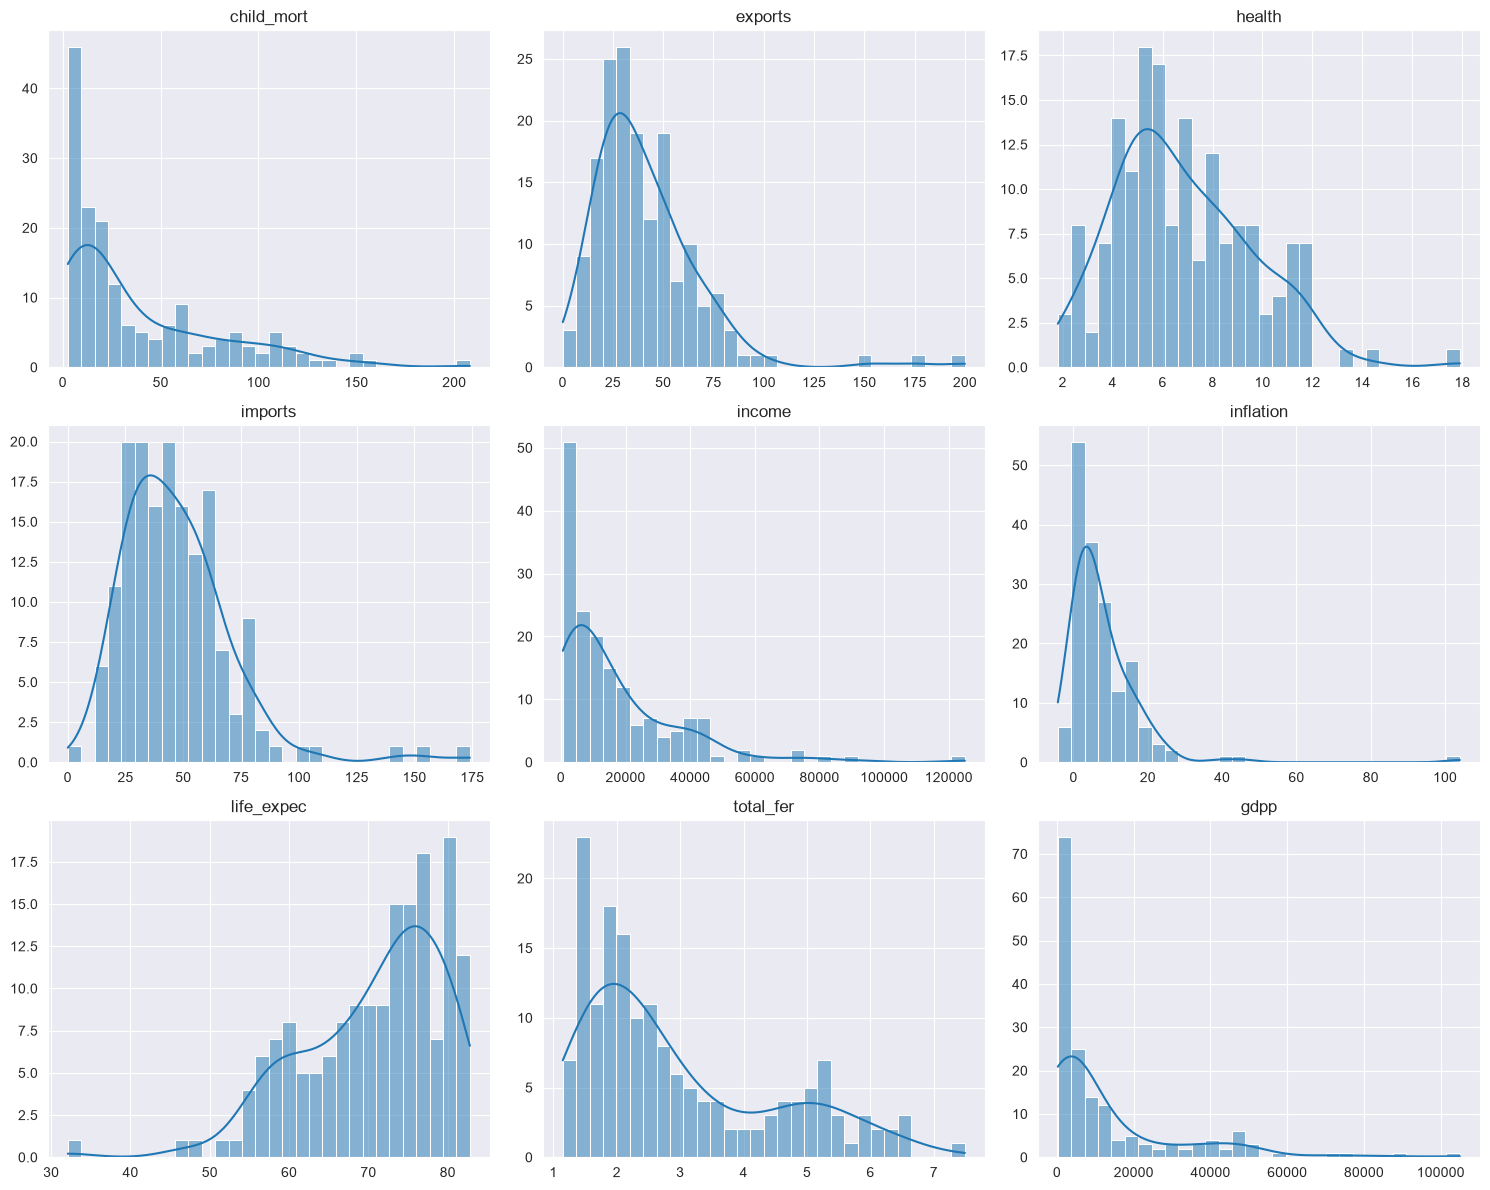

In [10]:
plot_all_histograms(df)

<Axes: >

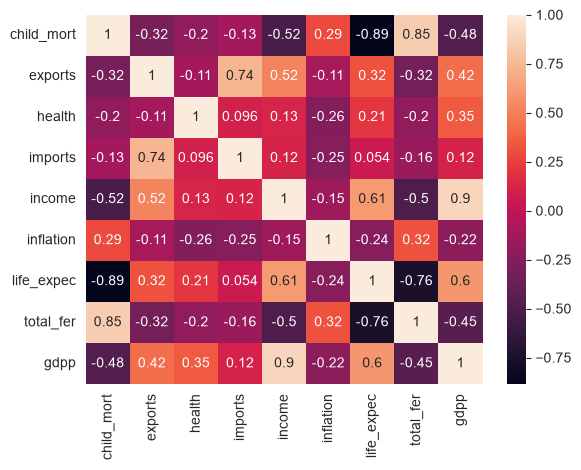

In [11]:
sns.heatmap(df.corr(), annot=True)

## ⚖️ 5. Özellik Ölçekleme / Feature Scaling

**🇹🇷 Türkçe:**
Orijinal `df` korunarak bir kopya (`df2`) üzerinde çalışılıyor. `MinMaxScaler`, her kolonu 0-1 aralığına sıkıştırıyor — bu, PCA ve K-Means gibi uzaklık tabanlı yöntemlerde `income` gibi büyük ölçekli kolonların sonucu domine etmesini önlüyor. Ölçekleme NumPy dizisi döndürdüğü için sonuç, orijinal kolon adlarıyla tekrar bir DataFrame'e çevrilip histogramlar yeniden çiziliyor — artık tüm değişkenler aynı [0,1] aralığında karşılaştırılabiliyor.

**🇬🇧 English:**
The original `df` is kept intact and a copy (`df2`) is used instead. `MinMaxScaler` compresses every column into the 0-1 range — this prevents large-scale columns like `income` from dominating distance-based methods such as PCA and K-Means. Since scaling returns a NumPy array, the result is converted back into a DataFrame with the original column names, and the histograms are replotted — now every variable is comparable on the same [0,1] range.

In [12]:
df2 = df.copy()

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
scaler = MinMaxScaler()

In [15]:
df2 = scaler.fit_transform(df2)

In [16]:
columns_name = df.columns

In [17]:
df2= pd.DataFrame(df2, columns=columns_name)

In [18]:
df2

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242
...,...,...,...,...,...,...,...,...,...
162,0.129503,0.232582,0.213797,0.302609,0.018820,0.063118,0.609467,0.370662,0.026143
163,0.070594,0.142032,0.192666,0.100809,0.127750,0.463081,0.854043,0.208202,0.126650
164,0.100779,0.359651,0.312617,0.460715,0.031200,0.150725,0.808679,0.126183,0.010299
165,0.261441,0.149536,0.209447,0.197397,0.031120,0.257000,0.698225,0.555205,0.010299


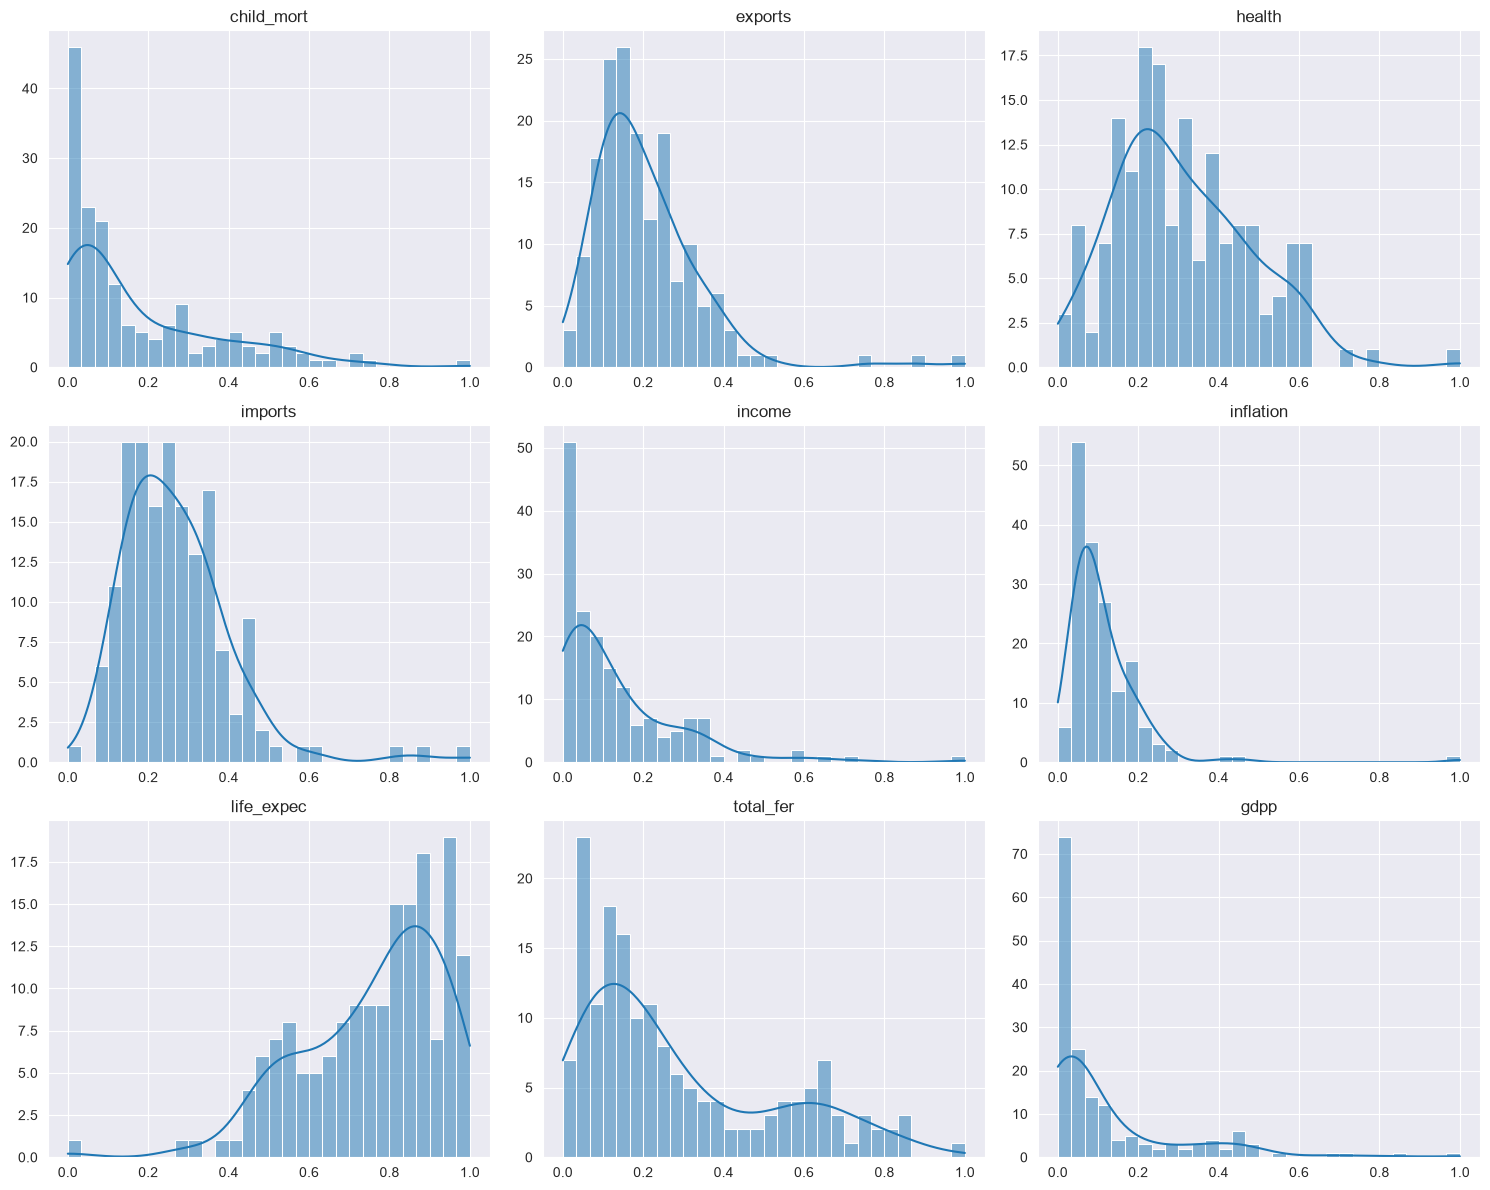

In [19]:
plot_all_histograms(df2)

## 🧮 6. Temel Bileşen Analizi (PCA) / Principal Component Analysis (PCA)

**🇹🇷 Türkçe:**
`PCA()` (bileşen sayısı sınırlanmadan) ölçeklenmiş 9 kolona uygulanıyor; bu, verideki varyansı en iyi açıklayan 9 ortogonal yön (temel bileşen) üretiyor. `explained_variance_` her bileşenin ne kadar bilgi taşıdığını gösteriyor, kümülatif varyans grafiği ise kaç bileşenin "yeterli" olduğuna karar vermeye yardımcı oluyor — ilk 3 bileşen, toplam varyansın yaklaşık %81'ini açıklıyor.

**🇬🇧 English:**
`PCA()` (with no component limit) is applied to the 9 scaled columns, producing 9 orthogonal directions (principal components) that best explain the variance in the data. `explained_variance_` shows how much information each component carries, and the cumulative variance plot helps decide how many components are "enough" — the first 3 components explain about 81% of the total variance.

In [20]:
from sklearn.decomposition import PCA

In [21]:
pca = PCA()

In [22]:
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

In [23]:
pca_df2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [24]:
pca.explained_variance_

array([0.14180615, 0.03450913, 0.03171502, 0.02513534, 0.00974048,
       0.00776992, 0.00306922, 0.00228894, 0.00178941])

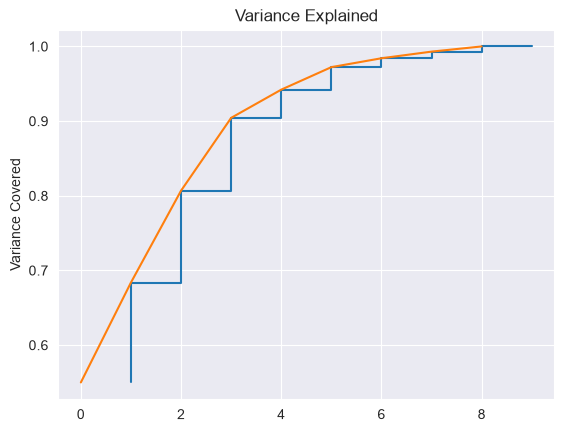

In [25]:
plt.step(list(range(1,10)), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covered")
plt.title("Variance Explained")
plt.show()

## ✂️ 7. Boyut İndirgeme Kararı / The Dimensionality-Reduction Decision

**🇹🇷 Türkçe:**
Kümülatif varyans grafiğindeki "dirsek"e dayanarak, sadece ilk 3 temel bileşen tutuluyor (kalan 6 kolon `drop` ediliyor). 9 boyuttan 3 boyuta inmek, bilginin büyük kısmını korurken hem görselleştirmeyi hem de sonraki K-Means adımını basitleştiriyor.

**🇬🇧 English:**
Based on the "elbow" in the cumulative variance plot, only the first 3 principal components are kept (the remaining 6 columns are dropped). Going from 9 dimensions down to 3 preserves most of the information while simplifying both visualization and the K-Means step that follows.

In [26]:
pca_df2 = pca_df2.drop(columns = [3,4,5,6,7,8])

In [27]:
pca_df2

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


## 🔢 8. K-Means için Küme Sayısını Seçme / Choosing K for K-Means

**🇹🇷 Türkçe:**
`k=1`'den `k=10`'a kadar her değer için bir `KMeans` modeli eğitilip küme içi kareler toplamı (`inertia_`, yani WCSS) kaydediliyor. WCSS'nin `k`'ye göre grafiği ("dirsek yöntemi"), eğrinin belirgin şekilde yavaşladığı noktayı — burada `k=3`'ü — makul bir küme sayısı adayı olarak işaret ediyor.

**🇬🇧 English:**
For every `k` from 1 to 10, a `KMeans` model is fit and the within-cluster sum of squares (`inertia_`, i.e. WCSS) is recorded. Plotting WCSS against `k` (the "elbow method") points to where the curve visibly flattens — here at `k=3` — as a reasonable candidate for the number of clusters.

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [29]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(pca_df2)
    wcss.append(kmeans.inertia_)

In [30]:
wcss

[34.53302925308178,
 17.68595420957709,
 11.270622261541497,
 9.026025307351238,
 7.2751574785455,
 6.40171424000018,
 6.053260166188537,
 4.753430293209606,
 4.549263069947241,
 4.109749033147687]

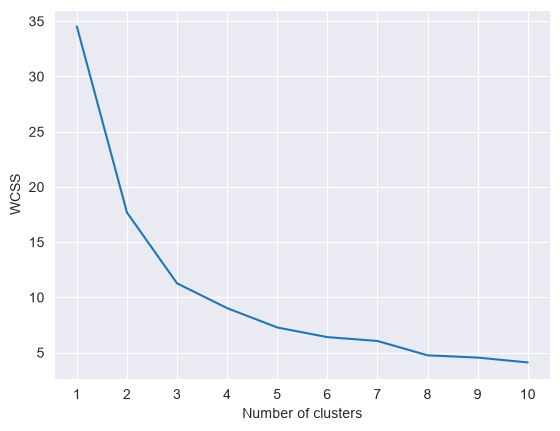

In [31]:
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

## 🎯 9. K-Means'i Eğitme ve Değerlendirme / Fitting K-Means & Evaluating It

**🇹🇷 Türkçe:**
Dirsek yöntemine dayanarak `n_clusters=3` ile son model eğitiliyor. `silhouette_score`, her noktanın kendi kümesine ne kadar iyi uyduğunu (kendi kümesine yakınlık ve diğer kümelere uzaklık) -1 ile 1 arasında özetliyor; burada 0.4386 çıkıyor — orta düzeyde belirgin, makul ölçüde iyi ayrılmış kümeler anlamına geliyor.

**🇬🇧 English:**
Based on the elbow method, the final model is fit with `n_clusters=3`. `silhouette_score` summarizes, on a -1 to 1 scale, how well each point fits its own cluster (closeness to its own cluster vs. distance to others); here it comes out to 0.4386 — moderately distinct, reasonably well-separated clusters.

In [32]:
model = KMeans(n_clusters=3, init='k-means++')
model.fit(pca_df2)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 3)",

In [33]:
labels = model.labels_

In [34]:
silhouette_score(pca_df2, labels)

0.4386320345236685

## 🔗 10. Kümeleri Geri Ekleme ve Yorumlama / Attaching Clusters Back & Interpreting Them

**🇹🇷 Türkçe:**
Küme etiketleri (`labels`) orijinal `df`'e `Class` olarak, ülke adları da (`country_column`) geri ekleniyor — artık her ülkenin hangi kümeye düştüğü görülebiliyor. `income` ve `child_mort`'a göre kümeleri karşılaştıran kutu grafikleri (boxplot), kümelerin gerçek anlamı hakkında sezgi veriyor: bir küme düşük gelir/yüksek çocuk ölüm oranıyla, bir diğeri yüksek gelir/düşük çocuk ölüm oranıyla öne çıkıyor.

**🇬🇧 English:**
The cluster labels (`labels`) are attached back to the original `df` as `Class`, and the country names (`country_column`) are re-attached too — now it's possible to see which cluster each country fell into. Boxplots comparing clusters by `income` and `child_mort` give intuition about what the clusters actually mean: one cluster stands out with low income/high child mortality, another with high income/low child mortality.

In [35]:
df["Class"] = labels

In [36]:
df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


In [37]:
df["country"] = country_column

In [38]:
df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class,country
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,Afghanistan
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,Albania
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,Algeria
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,Angola
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,Antigua and Barbuda
...,...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2,Vanuatu
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2,Venezuela
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2,Vietnam
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1,Yemen


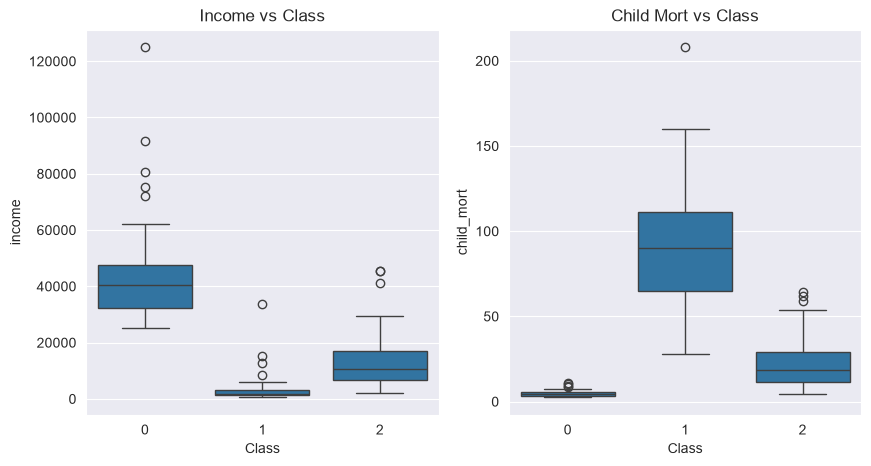

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x="Class", y="income")
plt.title("Income vs Class")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="Class", y="child_mort")
plt.title("Child Mort vs Class")

plt.show()

## 🗺️ 11. İnteraktif Dünya Haritası / Interactive World Map

**🇹🇷 Türkçe:**
`plotly.express` ile bir choropleth (koroplet) harita çiziliyor. Kümeler, yorumlanabilir etiketlere eşleniyor (`label_map`: 0 → "Bütçeye İhtiyaç Yok", 1 → "Bütçeye İhtiyaç Var", 2 → "Arada"), ve her ülke bu etikete göre renklendiriliyor (kırmızı/sarı/yeşil). Bu son adım, PCA + K-Means'in ürettiği soyut kümeleri, doğrudan gerçek dünya coğrafyasıyla ilişkilendirerek sonuçları hem teknik olmayan biri için de anlaşılır kılıyor.

**🇬🇧 English:**
A choropleth map is drawn with `plotly.express`. The clusters are mapped to interpretable labels (`label_map`: 0 → "No Budget Needed", 1 → "Budget Needed", 2 → "In Between"), and each country is colored accordingly (red/yellow/green). This final step ties the abstract clusters produced by PCA + K-Means directly to real-world geography, making the result understandable even to a non-technical audience.

In [40]:
import plotly.express as px

In [41]:
pca_df2.insert(0, column= "Country", value = df['country'])

In [42]:
pca_df2['Class'] = labels

In [44]:
label_map = {
    0: "No Budget Needed",
    1: "Budget Needed",
    2: "In Between"
}

pca_df2['Class'] = pca_df2['Class'].map(label_map)

In [45]:
pca_df2

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,In Between
163,Venezuela,-0.061133,-0.171339,-0.058586,In Between
164,Vietnam,-0.115512,-0.032034,-0.195243,In Between
165,Yemen,0.332968,-0.019824,-0.029989,Budget Needed


In [46]:
fig = px.choropleth(
    pca_df2[['Country', 'Class']],
    locationmode = "country names",
    locations = "Country",
    title = "Needed Budget by Country",
    color = pca_df2['Class'],
    color_discrete_map= {
                        "Budget Needed" : "Red",
                        "In Between" : "Yellow",
                        "No Budget Needed": "Green"
    })
fig.update_geos(fitbounds = "locations", visible = True)
fig.show()

C:\Users\efeka\AppData\Local\Temp\ipykernel_17932\2955979379.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
;